# Parte 2 — Análise Estatística da Inadimplência
### Teste Técnico · Analista de Dados Pleno · FinLend (Lending Club)

**Contexto.** O Head de Risco afirma:
> *"A inadimplência está subindo porque estamos aprovando muitos empréstimos de Grade D e E."*

Este notebook investiga essa hipótese — e vai além dela. A estrutura segue quatro etapas:

1. **Análise exploratória** da inadimplência
2. **Teste de hipótese** sobre a afirmação do Head de Risco
3. **Um insight não-óbvio** que muda a leitura do problema
4. **Recomendação ao negócio**

---
**Sobre a amostra.** Trabalhamos com ~100 mil empréstimos (amostra estratificada por *grade*, safras de 2016 a 2018 — os últimos 2 anos do dataset), extraída do *Lending Club Loan Data* (Kaggle).

**Uso de IA assistiva.** Conforme permitido no enunciado, usei um assistente de IA para acelerar a escrita de código (estruturação do notebook, sintaxe de `scipy.stats`) e para revisar o raciocínio estatístico. Todas as decisões analíticas, interpretações e conclusões foram validadas por mim contra os dados.

## 0. Setup e carga dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True

# Caminho do CSV gerado na etapa de extração (separador ';', decimal '.').
# Ajuste o caminho se necessário.
CAMINHO = "base_looker_finlend.csv"
df = pd.read_csv(CAMINHO, sep=';')
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%d/%m/%Y', errors='coerce')

print("Registros:", len(df))
print("Período:", df['issue_d'].min().date(), "→", df['issue_d'].max().date())
df.head(3)

Registros: 99999
Período: 2016-12-01 → 2018-12-01


,id,issue_d,ano_mes,ano,valor_emprestimo,taxa_juros,parcela,term_meses,grade,sub_grade,...,faixa_renda,dti,faixa_dti,finalidade,estado,status_verificacao,moradia,loan_status,status_carteira,inadimplente
0,134467986,2018-05-01,01/05/2018,2018,11000.0,6.83,338.80,36.0,A,A3,...,50k-75k,17.26,out/20,debt_consolidation,FL,Not Verified,RENT,Current,Em dia,0
1,120555113,2017-10-01,01/10/2017,2017,35000.0,7.21,1084.07,36.0,A,A3,...,150k+,25.06,20-30,credit_card,NC,Verified,MORTGAGE,Current,Em dia,0
2,130024561,2018-03-01,01/03/2018,2018,36000.0,7.34,1117.19,36.0,A,A4,...,75k-100k,23.08,20-30,debt_consolidation,NJ,Source Verified,OWN,Current,Em dia,0


### Definição de *inadimplente* (decisão explícita)

Antes de qualquer número, é preciso definir o que conta como inadimplência — essa é uma **decisão de negócio**, não apenas técnica, e toda a análise depende dela. Adotamos:

| `loan_status` | Classificação |
|---|---|
| Charged Off, Default, Late (31-120 days) | **Inadimplente (1)** |
| Fully Paid, Current, In Grace Period, Late (16-30 days) | Adimplente (0) |

O critério inclui atrasos acima de 30 dias (`Late 31-120`), por já representarem risco material. Essa flag (`inadimplente`) foi criada na extração e é usada em todo o notebook.

In [2]:
# A flag já vem pronta do CSV; conferimos a consistência com loan_status
print(df.groupby('loan_status')['inadimplente'].mean().sort_values(ascending=False))
print()
print("Taxa de inadimplência geral: {:.2f}%".format(df['inadimplente'].mean()*100))

loan_status
Charged Off           1.0
Default               1.0
Late (31-120 days)    1.0
Current               0.0
Fully Paid            0.0
In Grace Period       0.0
Late (16-30 days)     0.0
Name: inadimplente, dtype: float64

Taxa de inadimplência geral: 7.02%


## 1. Análise exploratória da inadimplência

Começamos com os cortes mais relevantes: por *grade*, ao longo do tempo e por finalidade.

### 1.1 Inadimplência por *grade*

O *grade* (A a G) é a classificação de risco atribuída pela plataforma na originação. Esperamos uma relação monotônica com a inadimplência.

        taxa  volume
grade               
A       1.69   22414
B       4.73   29265
C       8.63   29143
D      11.90   13493
E      16.71    4213
F      27.31    1029
G      34.39     442


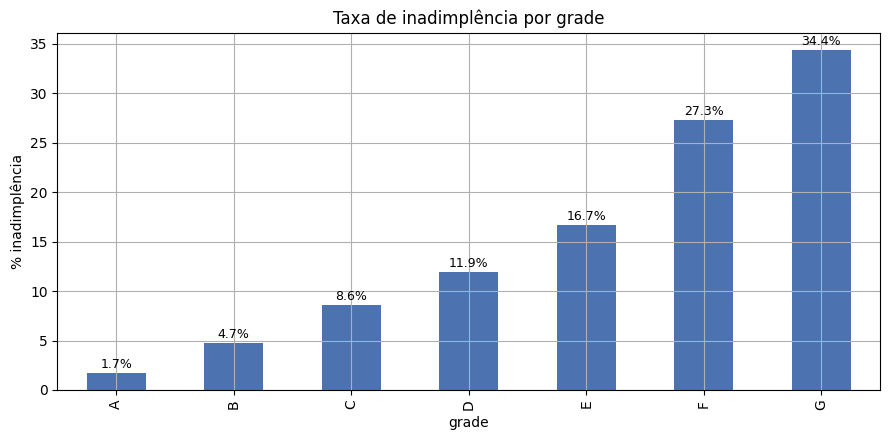

In [3]:
por_grade = df.groupby('grade')['inadimplente'].agg(
    taxa=lambda s: s.mean()*100, volume='count'
).round(2)
print(por_grade)

ax = por_grade['taxa'].plot(kind='bar', color='#4C72B0')
ax.set_title('Taxa de inadimplência por grade')
ax.set_ylabel('% inadimplência'); ax.set_xlabel('grade')
for i, v in enumerate(por_grade['taxa']):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Leitura.** A inadimplência cresce de forma perfeitamente monotônica: **A ≈ 1,7%** até **G ≈ 34,4%**. O *grade* claramente carrega sinal de risco.

Mas repare já num ponto que será central: as grades de maior risco (F, G) concentram **pouquíssimo volume** (~1.000 e ~440 empréstimos), enquanto o grosso da carteira está em A, B e C. Ou seja, a taxa alta de G impacta pouco o agregado. Guardaremos isso para o teste de hipótese.

### 1.2 Inadimplência ao longo do tempo (visão crua)

Como a premissa do case é que *"a inadimplência está subindo"*, olhamos a taxa por safra de originação.

issue_d
2016    15.31
2017    10.53
2018     3.24
Name: inadimplente, dtype: float64


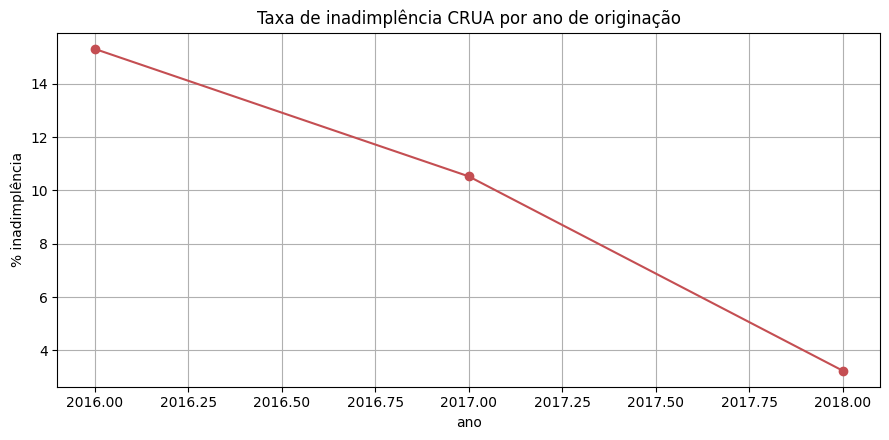

In [4]:
por_ano = df.groupby(df['issue_d'].dt.year)['inadimplente'].mean()*100
print(por_ano.round(2))

ax = por_ano.plot(marker='o', color='#C44E52')
ax.set_title('Taxa de inadimplência CRUA por ano de originação')
ax.set_ylabel('% inadimplência'); ax.set_xlabel('ano')
plt.tight_layout(); plt.show()

**Aqui já há um paradoxo.** A taxa crua **cai** de 15,3% (2016) para 3,2% (2018) — o oposto do que o Head de Risco supõe. Isso *não* significa que a carteira melhorou. A explicação está na Seção 3 (é o insight não-óbvio), e é o achado mais importante deste notebook. Por ora, apenas registramos que a leitura ingênua da série temporal é enganosa.

### 1.3 Inadimplência por finalidade do empréstimo

In [5]:
por_fin = df.groupby('finalidade')['inadimplente'].agg(
    taxa=lambda s: s.mean()*100, volume='count'
).round(2).sort_values('taxa', ascending=False)
print(por_fin)

                     taxa  volume
finalidade                       
small_business      11.21     990
moving              10.43     700
other                8.39    7297
major_purchase       8.08    2501
medical              8.05    1478
vacation             7.71     739
house                7.58     871
debt_consolidation   7.50   53924
home_improvement     6.51    7147
car                  5.60    1142
credit_card          5.21   23148
renewable_energy     4.84      62


**Leitura.** `small_business` (11,2%) e `moving` (10,4%) lideram, bem acima de `debt_consolidation` (7,5%), que é a maior fatia da carteira. A finalidade carrega sinal de risco próprio — retomamos isso na Seção 3.

## 2. Teste de hipótese

A afirmação do Head de Risco parece uma frase só, mas embute **duas afirmações distintas** que precisam ser testadas separadamente:

- **Afirmação A** — *Empréstimos D/E são mais inadimplentes que os demais.* (relação grade × inadimplência)
- **Afirmação B** — *Estamos aprovando **mais** D/E ao longo do tempo* — é isso que faria a inadimplência **subir**. (mudança de mix)

A frase só é verdadeira **se A e B forem ambas verdadeiras**. Testamos cada uma.

### 2.1 Afirmação A — D/E são mais arriscados?

**Teste 1 — Qui-quadrado de independência** entre `grade` e `inadimplente`.
$H_0$: grade e inadimplência são independentes. $H_1$: há associação.

In [6]:
ct = pd.crosstab(df['grade'], df['inadimplente'])
chi2, p, dof, esp = stats.chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print(f"Qui-quadrado = {chi2:,.1f}")
print(f"p-valor      = {p:.2e}")
print(f"Cramér's V   = {cramers_v:.3f}  (tamanho do efeito)")

Qui-quadrado = 3,579.5
p-valor      = 0.00e+00
Cramér's V   = 0.189  (tamanho do efeito)


**Teste 2 — Diferença de proporções** entre o grupo {D,E} e as demais grades (teste z para duas proporções).

In [7]:
df['grupo'] = np.where(df['grade'].isin(['D','E']), 'D/E', 'Outras')
tab = df.groupby('grupo')['inadimplente'].agg(inadimp='sum', n='count')
tab['taxa_%'] = (tab['inadimp']/tab['n']*100).round(2)
print(tab)

# teste z para duas proporções (implementado com scipy, sem dependências extras)
x1, x2 = tab.loc['D/E','inadimp'], tab.loc['Outras','inadimp']
n1, n2 = tab.loc['D/E','n'],       tab.loc['Outras','n']
p1, p2 = x1/n1, x2/n2
p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (p1 - p2) / se
pz = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"\nz = {z:.2f} | p-valor = {pz:.2e}")

        inadimp      n  taxa_%
grupo                         
D/E        2310  17706   13.05
Outras     4711  82293    5.72

z = 34.59 | p-valor = 0.00e+00


**Conclusão da Afirmação A — VERDADEIRA.** O qui-quadrado rejeita a independência com $p < 0{,}001$ (Cramér's V ≈ 0,19, efeito pequeno-a-moderado). O grupo D/E inadimple **13,05%** contra **5,72%** das demais — mais que o dobro, diferença altamente significativa. O Head está certo *nesta parte*.

### 2.2 Afirmação B — o mix de D/E aumentou ao longo do tempo?

Esta é a parte que sustentaria a **causalidade** (mais D/E → inadimplência subindo). Medimos a **proporção de originações D/E por período**.

% de originações D/E por ano:
issue_d
2016    21.15
2017    17.10
2018    18.00
dtype: float64


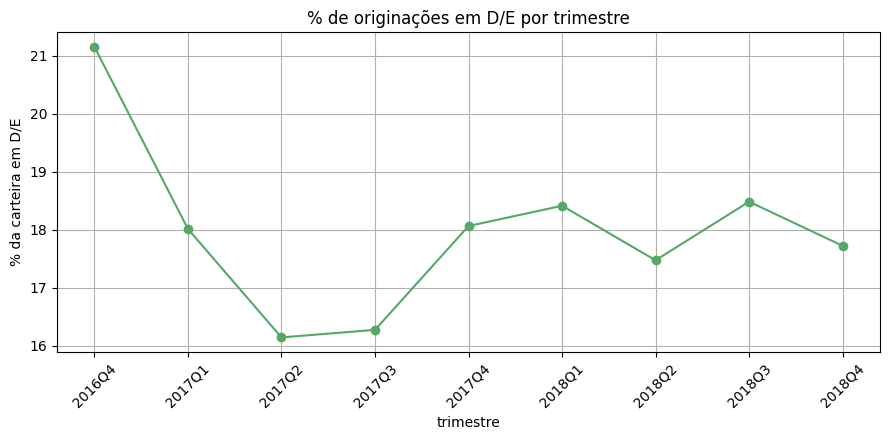

In [8]:
df['trimestre'] = df['issue_d'].dt.to_period('Q').astype(str)
mix_ano = df.groupby(df['issue_d'].dt.year).apply(
    lambda x: x['grade'].isin(['D','E']).mean()*100, include_groups=False
).round(2)
print("% de originações D/E por ano:")
print(mix_ano)

mix_q = df.groupby('trimestre').apply(
    lambda x: x['grade'].isin(['D','E']).mean()*100, include_groups=False
).round(2)
ax = mix_q.plot(marker='o', color='#55A868')
ax.set_title('% de originações em D/E por trimestre')
ax.set_ylabel('% da carteira em D/E')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Conclusão da Afirmação B — FALSA.** A proporção de D/E **não subiu** — ela **caiu** de ~21% (2016) para ~18% (2018), e ficou estável em torno de 17-18% ao longo dos trimestres. A empresa não está aprovando *mais* D/E; se algo, está aprovando *proporcionalmente menos*.

### 2.3 Veredito sobre a hipótese do Head de Risco

| Afirmação | Resultado |
|---|---|
| A — D/E são mais arriscados | ✅ **Verdadeira** (χ² p<0,001; 13,05% vs 5,72%) |
| B — Estamos aprovando mais D/E (→ causa do aumento) | ❌ **Falsa** (mix caiu de 21% para 18%) |

**A hipótese está parcialmente correta, mas a relação causal proposta não se sustenta.** D/E realmente inadimplem mais, mas não podem explicar um *aumento* da inadimplência, porque sua participação na carteira **diminuiu**. O Head confundiu *"D/E é arriscado"* (fato) com *"D/E está puxando a inadimplência para cima"* (não comprovado pelos dados).

Isso abre a pergunta certa: **a inadimplência está mesmo subindo?** — que nos leva ao insight não-óbvio.

## 3. Insight não-óbvio — o viés de maturação (*vintage*) mascara tudo

Na Seção 1.2 a taxa crua **caía** (15% → 3%). Isso é uma **ilusão estatística** causada pela imaturidade das safras recentes. A prova:

In [9]:
# Quanto de cada safra ainda está "Current" (empréstimo em curso, sem desfecho)?
comp = pd.crosstab(df['issue_d'].dt.year, df['loan_status'], normalize='index')*100
pct_current = comp['Current'].round(1)
print("% da safra ainda 'Current' (não amadurecida):")
print(pct_current)

% da safra ainda 'Current' (não amadurecida):


issue_d
2016    43.9
2017    58.9
2018    86.3
Name: Current, dtype: float64


**86% dos empréstimos de 2018 ainda estão `Current`** — mal começaram a ser pagos. Um empréstimo de 36-60 meses originado em 2018 **não teve tempo de inadimplir** até a data de corte do dataset. A taxa "baixa" de 2018 não é qualidade de crédito: é **falta de tempo**.

A forma correta de comparar safras é olhar apenas empréstimos **já resolvidos** (quitados ou perdidos), removendo os que ainda estão em curso:

In [10]:
resolvidos = df[df['loan_status'].isin(['Fully Paid','Charged Off','Default'])].copy()
resolvidos['mau'] = resolvidos['loan_status'].isin(['Charged Off','Default']).astype(int)
tx = resolvidos.groupby(resolvidos['issue_d'].dt.year)['mau'].agg(
    taxa=lambda s: s.mean()*100, n='count').round(2)

comparacao = pd.DataFrame({
    'taxa_crua_%': (df.groupby(df['issue_d'].dt.year)['inadimplente'].mean()*100).round(2),
    'pct_ainda_current': pct_current,
    'taxa_entre_resolvidos_%': tx['taxa'],
})
print(comparacao)

         taxa_crua_%  pct_ainda_current  taxa_entre_resolvidos_%
issue_d                                                         
2016           15.31               43.9                    25.56
2017           10.53               58.9                    22.90
2018            3.24               86.3                    15.56


**Leitura.** A taxa crua (3,2% em 2018) e a taxa entre resolvidos (15,6% em 2018) contam histórias opostas. A verdade é que **não é possível medir a inadimplência de safras recentes** com os dados atuais — elas não maturaram. Qualquer afirmação do tipo *"a inadimplência subiu/caiu no último trimestre"* feita sobre a taxa crua é **não-confiável por construção**.

> **Insight não-óbvio:** o dado cru sugere que a inadimplência despencou; na verdade, as safras recentes apenas não tiveram tempo de inadimplir. A premissa original do case ("a inadimplência subiu") não é nem confirmável nem refutável com a métrica crua — ela exige **análise de safra (*vintage analysis*)** com janela de maturação fixa.

*(Insights secundários no apêndice: a finalidade carrega risco além do grade, e o retorno esperado despenca em F/G.)*

## 4. Recomendação ao negócio

**1. Não frear D/E com base na premissa atual.** D/E são mais arriscados (fato), mas sua participação caiu, não subiu — cortá-los não ataca a causa de nenhum aumento de inadimplência e sacrificaria retorno. A decisão precisa vir de análise de safra madura, não da taxa agregada.

**2. Adotar análise de safra (*vintage*) como métrica oficial de risco.** Medir inadimplência em **janela fixa de maturação** (ex.: % inadimplente nos primeiros 12 meses de cada safra). É a única forma de comparar 2016, 2017 e 2018 de maneira justa e detectar deterioração real de crédito antes que ela apareça (tarde) na taxa agregada.

**3. Incorporar a finalidade ao apetite de risco.** `small_business` inadimple mais **mesmo dentro das grades boas** (7,5% vs 5,3% em A/B/C). O grade não captura tudo; a finalidade deveria entrar na política de aprovação/precificação.

**4. Reavaliar apetite em F/G.** O retorno esperado ajustado por risco é marginal nas piores grades (ver apêndice): a inadimplência de 27-34% consome quase todo o prêmio de juros. Vale questionar se o volume (pequeno) dessas grades justifica a exposição.

**5. Ponte com a Parte 3 (validação de IA).** Este caso é um lembrete de que **um número plausível pode estar errado** (a taxa crua "parecia" informativa). Qualquer agente de IA que responda sobre a carteira precisa ser validado justamente contra esse tipo de armadilha — é o que a Parte 3 aborda.

## Apêndice — insights secundários

### A.1 A finalidade carrega risco além do *grade*

In [11]:
bons = df[df['grade'].isin(['A','B','C'])]
sb = bons[bons['finalidade']=='small_business']['inadimplente'].mean()*100
outros = bons[bons['finalidade']!='small_business']['inadimplente'].mean()*100
print(f"Dentro de grades A/B/C:")
print(f"  small_business : {sb:.2f}%")
print(f"  demais         : {outros:.2f}%")
print("→ small_business é ~40% mais arriscado mesmo controlando por grade boa.")

Dentro de grades A/B/C:
  small_business : 7.45%
  demais         : 5.27%
→ small_business é ~40% mais arriscado mesmo controlando por grade boa.


### A.2 Retorno esperado por grade (curva de risco-retorno)

Aproximação ilustrativa: `retorno ≈ (1−PD)·juros − PD·LGD`, com PD = taxa de inadimplência observada e LGD (perda dado o default) = 55% (proxy típico de crédito não-garantido). **As premissas são simplificadas — serve para mostrar o formato da curva, não para decisão de pricing.**

In [12]:
LGD = 0.55
g = df.groupby('grade').agg(juros=('taxa_juros','mean'), pd_=('inadimplente','mean'))
g['retorno_esperado_%'] = ((1-g['pd_'])*g['juros']/100 - g['pd_']*LGD)*100
g['juros'] = g['juros'].round(2)
g['PD_%'] = (g['pd_']*100).round(2)
print(g[['juros','PD_%','retorno_esperado_%']].round(2))

       juros   PD_%  retorno_esperado_%
grade                                  
A       7.04   1.69                5.99
B      10.73   4.73                7.62
C      14.45   8.63                8.46
D      19.14  11.90               10.32
E      24.87  16.71               11.53
F      29.66  27.31                6.54
G      30.87  34.39                1.34


**Leitura.** O retorno esperado sobe até E e **despenca em F/G** — a inadimplência cresce mais rápido que o prêmio de juros. Reforça a recomendação nº 4: as piores grades podem não compensar o risco.